In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# ----------------------------------------------------------------------
# Load the team's shared, fully-merged monthly table.
# Combined_Monthly_Data.csv already has correct lag columns built in,
# so we no longer need to compute lags ourselves.
# ----------------------------------------------------------------------
salt_data = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
salt_data["Time"] = pd.to_datetime(salt_data["Time"])
salt_data = salt_data.sort_values("Time").reset_index(drop=True)

In [3]:
# ----------------------------------------------------------------------
# Quick sanity check - see what's missing and where
# ----------------------------------------------------------------------
print("Full table:", salt_data.Time.min().date(), "to", salt_data.Time.max().date(),
      f"({len(salt_data)} rows)")
print()
salt_cols = [c for c in salt_data.columns if "salt" in c.lower()] + \
            ["Temp_Maricopa", "Precip_Maricopa", "Population", "IrrigatedLand_Acres",
             "datacenters_TotalMW", "datacenters_TotalNum"]
print("NaN count per column (Salt-relevant):")
print(salt_data[salt_cols].isna().sum())
print()

# ----------------------------------------------------------------------
# Build the UPSTREAM modeling table
# Features: watershed precip, watershed temp, lagged upstream flow
# ----------------------------------------------------------------------
upstream_lag_cols = [f"log_flow_salt_upstream_lag_{i}" for i in range(1, 13)]
upstream_feature_cols = ["Precip_Salt", "Temp_Salt"] + upstream_lag_cols
upstream_target = "log_flow_salt_upstream"

upstream_data = salt_data.dropna(subset=[upstream_target] + upstream_feature_cols).reset_index(drop=True)

print("Upstream model data:", upstream_data.Time.min().date(), "to", upstream_data.Time.max().date(),
      f"({len(upstream_data)} rows)")

# ----------------------------------------------------------------------
# Build the DOWNSTREAM modeling table
# Features: population, irrigated acres, data centers, county climate,
# lagged downstream flow, and THIS MONTH'S upstream flow (not lagged -
# matches the final model convention, since water entering upstream
# this month is roughly what's available to release downstream this
# same month)
# ----------------------------------------------------------------------
downstream_lag_cols = [f"log_flow_salt_downstream_lag_{i}" for i in range(1, 13)]
downstream_feature_cols = [
    "Population", "IrrigatedLand_Acres",
    "datacenters_TotalMW", "datacenters_TotalNum",
    "Temp_Maricopa", "Precip_Maricopa",
    "log_flow_salt_upstream", "log_flow_salt_upstream_lag_1",
] + downstream_lag_cols
downstream_target = "log_flow_salt_downstream"

downstream_data = salt_data.dropna(subset=[downstream_target] + downstream_feature_cols).reset_index(drop=True)

print("Downstream model data:", downstream_data.Time.min().date(), "to", downstream_data.Time.max().date(),
      f"({len(downstream_data)} rows)")

Full table: 1904-01-01 to 2026-05-01 (1469 rows)

NaN count per column (Salt-relevant):
flow_salt_upstream                 128
log_flow_salt_upstream             128
flow_salt_downstream               416
log_flow_salt_downstream           416
Temp_Salt                            0
Precip_Salt                          0
log_flow_salt_downstream_lag_1     417
log_flow_salt_downstream_lag_2     418
log_flow_salt_downstream_lag_3     419
log_flow_salt_downstream_lag_4     420
log_flow_salt_downstream_lag_5     421
log_flow_salt_downstream_lag_6     422
log_flow_salt_downstream_lag_7     423
log_flow_salt_downstream_lag_8     424
log_flow_salt_downstream_lag_9     425
log_flow_salt_downstream_lag_10    426
log_flow_salt_downstream_lag_11    427
log_flow_salt_downstream_lag_12    428
log_flow_salt_upstream_lag_1       128
log_flow_salt_upstream_lag_2       128
log_flow_salt_upstream_lag_3       128
log_flow_salt_upstream_lag_4       128
log_flow_salt_upstream_lag_5       128
log_flow_salt_u

In [4]:
# find actual gaps in the downstream modeling window
full_range = pd.date_range(downstream_data.Time.min(), downstream_data.Time.max(), freq="MS")
missing_months = full_range.difference(downstream_data.Time)
print(f"{len(missing_months)} missing months")
print(missing_months)

59 missing months
DatetimeIndex(['1979-10-01', '1979-11-01', '1979-12-01', '1980-01-01',
               '1980-02-01', '1980-03-01', '1980-04-01', '1980-05-01',
               '1980-06-01', '1980-07-01', '1980-08-01', '1980-09-01',
               '1980-10-01', '1980-11-01', '1980-12-01', '1981-01-01',
               '1981-02-01', '1981-03-01', '1981-04-01', '1981-05-01',
               '1981-06-01', '1981-07-01', '1981-08-01', '1981-09-01',
               '1981-10-01', '1981-11-01', '1981-12-01', '1982-01-01',
               '1982-02-01', '1982-03-01', '1982-04-01', '1982-05-01',
               '1982-06-01', '1982-07-01', '1982-08-01', '1982-09-01',
               '1982-10-01', '1982-11-01', '1982-12-01', '1983-01-01',
               '1983-02-01', '1983-03-01', '1983-04-01', '1983-05-01',
               '1983-06-01', '1983-07-01', '1983-08-01', '1983-09-01',
               '1983-10-01', '1983-11-01', '1983-12-01', '1984-01-01',
               '1984-02-01', '1984-03-01', '1984-04-01', '1

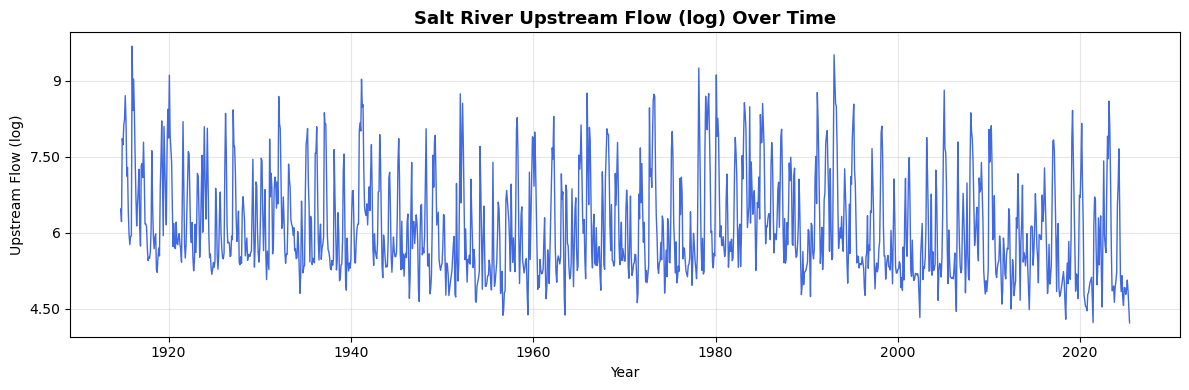

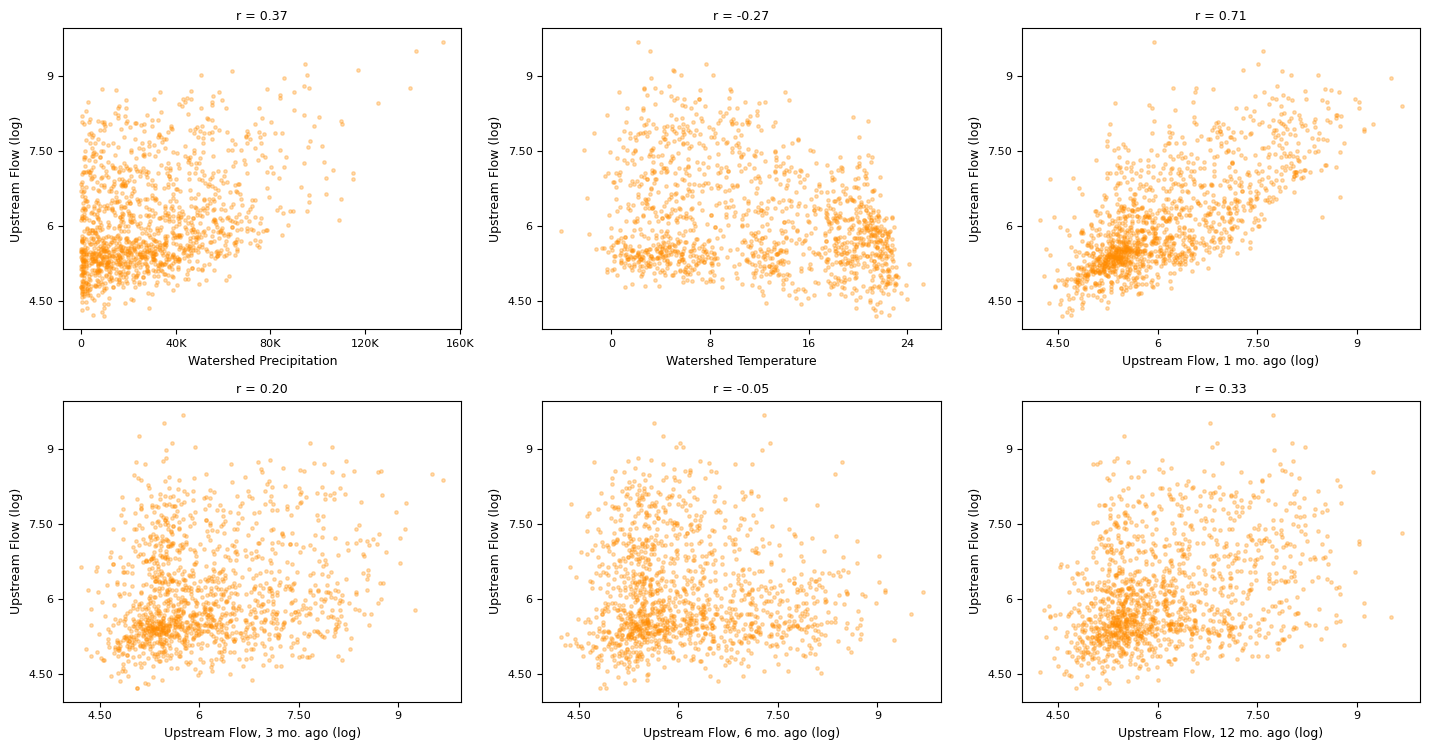

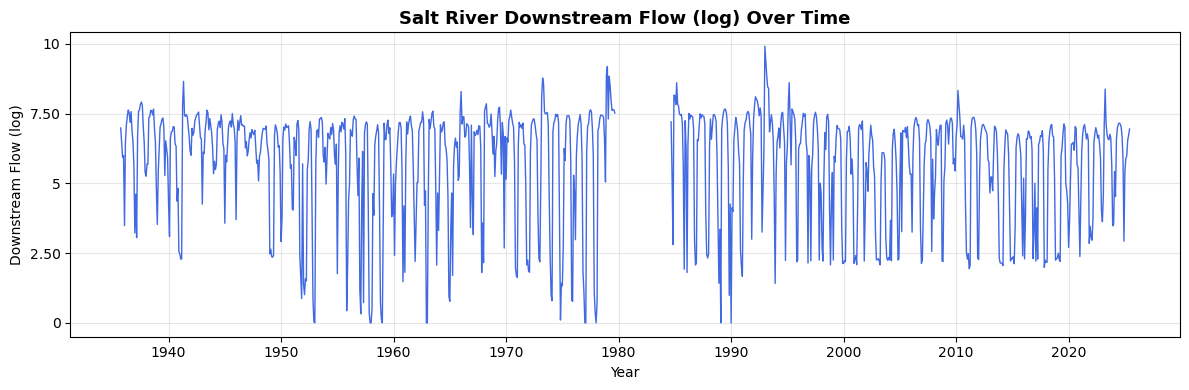

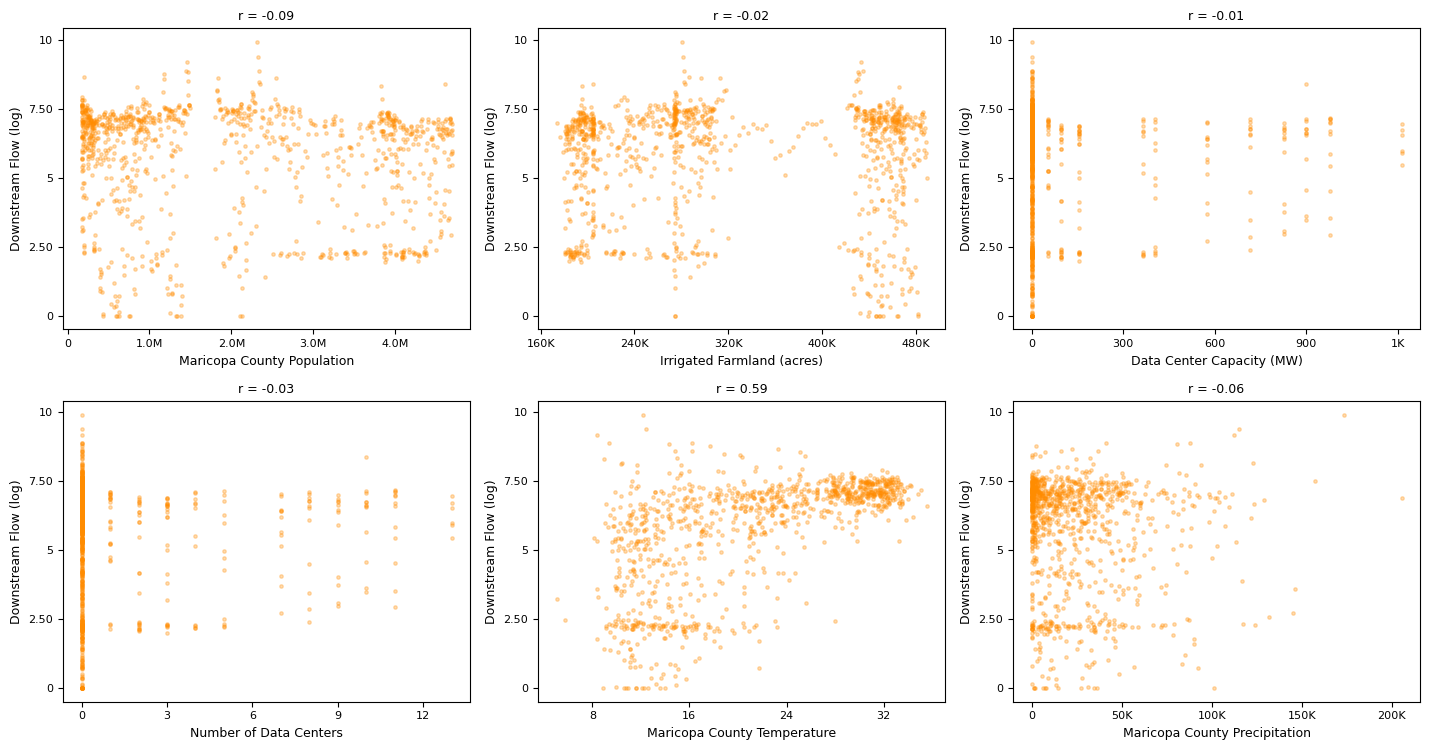

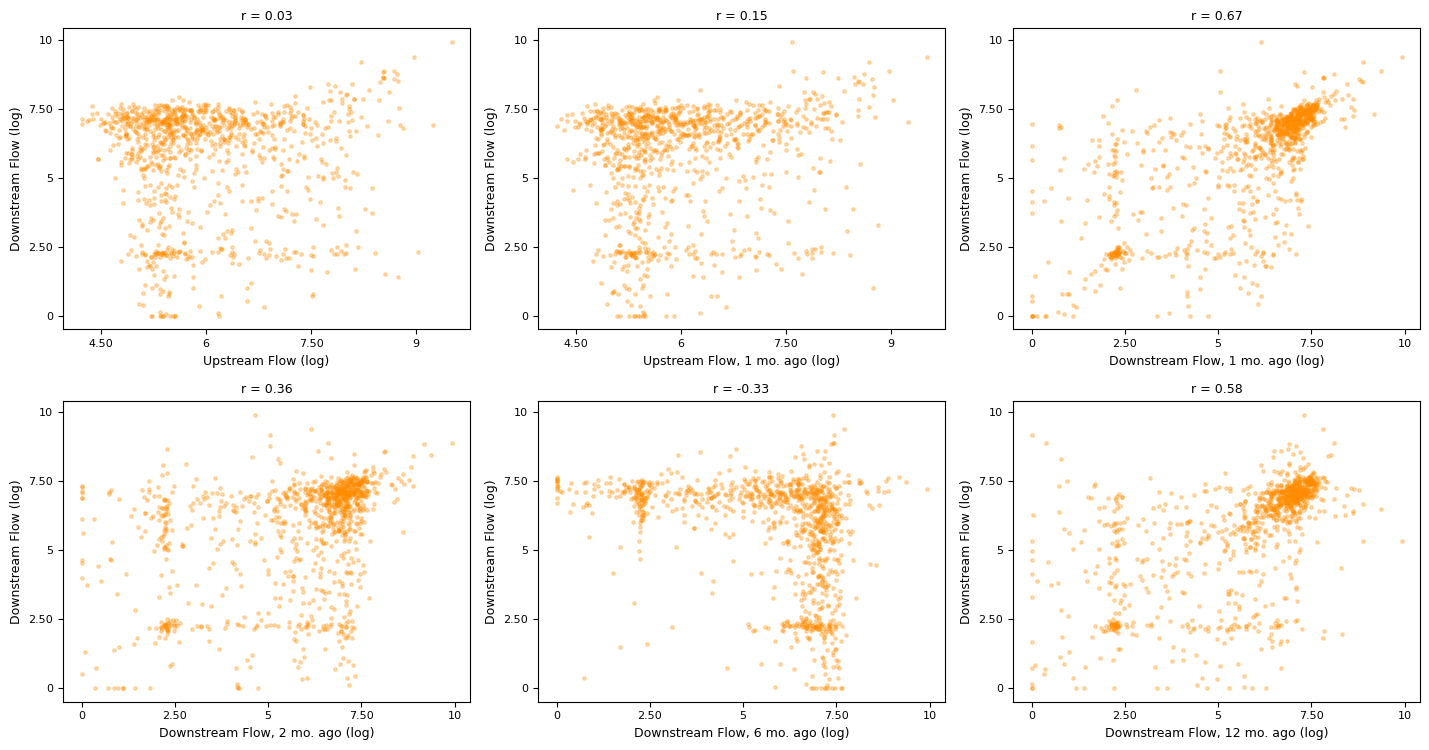

In [5]:
# ----------------------------------------------------------------------
# Human-readable labels, so plots show meaningful names instead of
# raw column names like "log_flow_salt_upstream"
# ----------------------------------------------------------------------
NICE_LABELS = {
    "log_flow_salt_upstream": "Upstream Flow (log)",
    "log_flow_salt_downstream": "Downstream Flow (log)",
    "Precip_Salt": "Watershed Precipitation",
    "Temp_Salt": "Watershed Temperature",
    "Temp_Maricopa": "Maricopa County Temperature",
    "Precip_Maricopa": "Maricopa County Precipitation",
    "Population": "Maricopa County Population",
    "IrrigatedLand_Acres": "Irrigated Farmland (acres)",
    "datacenters_TotalMW": "Data Center Capacity (MW)",
    "datacenters_TotalNum": "Number of Data Centers",
}
for i in range(1, 13):
    NICE_LABELS[f"log_flow_salt_upstream_lag_{i}"] = f"Upstream Flow, {i} mo. ago (log)"
    NICE_LABELS[f"log_flow_salt_downstream_lag_{i}"] = f"Downstream Flow, {i} mo. ago (log)"

def nice_label(col):
    return NICE_LABELS.get(col, col)


def _clean_axis_numbers(axis):
    """Abbreviates large numbers (150000 -> 150K) and caps the tick count
    so labels don't overlap or crowd each other out."""
    axis.set_major_locator(mticker.MaxNLocator(nbins=5))
    def fmt(x, pos):
        if abs(x) >= 1_000_000:
            return f"{x/1_000_000:.1f}M"
        if abs(x) >= 1_000:
            return f"{x/1_000:.0f}K"
        return f"{int(x)}" if float(x).is_integer() else f"{x:.2f}"
    axis.set_major_formatter(mticker.FuncFormatter(fmt))


def plot_time_series(data, target_col, title):
    # Reindex onto the complete monthly calendar so real gaps in the data
    # (like the Salt downstream gage outage from 1979-1984) show up as a
    # visible break in the line, rather than a straight line that would
    # misleadingly connect across years we have no data for.
    full_index = pd.date_range(data["Time"].min(), data["Time"].max(), freq="MS")
    series = data.set_index("Time")[target_col].reindex(full_index)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(series.index, series.values, linewidth=1, color="royalblue")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(nice_label(target_col))
    _clean_axis_numbers(ax.yaxis)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_features_vs_target(data, feature_cols, target_col, ncols=3):
    n = len(feature_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        ax.scatter(data[col], data[target_col], s=6, alpha=0.3, color="darkorange")
        ax.set_xlabel(nice_label(col), fontsize=9)
        ax.set_ylabel(nice_label(target_col), fontsize=9)
        _clean_axis_numbers(ax.xaxis)
        _clean_axis_numbers(ax.yaxis)
        ax.tick_params(labelsize=8)
        r = np.corrcoef(data[col], data[target_col])[0, 1]
        ax.set_title(f"r = {r:.2f}", fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


# Upstream
plot_time_series(upstream_data, "log_flow_salt_upstream", "Salt River Upstream Flow (log) Over Time")
plot_features_vs_target(upstream_data,
    ["Precip_Salt", "Temp_Salt", "log_flow_salt_upstream_lag_1",
     "log_flow_salt_upstream_lag_3", "log_flow_salt_upstream_lag_6", "log_flow_salt_upstream_lag_12"],
    "log_flow_salt_upstream")

# Downstream
plot_time_series(downstream_data, "log_flow_salt_downstream", "Salt River Downstream Flow (log) Over Time")
plot_features_vs_target(downstream_data,
    ["Population", "IrrigatedLand_Acres", "datacenters_TotalMW",
     "datacenters_TotalNum", "Temp_Maricopa", "Precip_Maricopa"],
    "log_flow_salt_downstream")
# NOTE: log_flow_salt_upstream (current month, first panel below) is the one
# actually used in the final model - shown alongside its lagged version and
# downstream's own lags for comparison.
plot_features_vs_target(downstream_data,
    ["log_flow_salt_upstream", "log_flow_salt_upstream_lag_1",
     "log_flow_salt_downstream_lag_1", "log_flow_salt_downstream_lag_2",
     "log_flow_salt_downstream_lag_6", "log_flow_salt_downstream_lag_12"],
    "log_flow_salt_downstream")